<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-07-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação baseados em Multi-Layer Perceptrons (MLPs).

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:

- correto
- reproduzível
- rastreável
- criticamente analisado

Além disso, utilizaremos o MLflow para registrar:

- hiperparâmetros
- métricas
- execuções
- comparações
- experimentais

In [ ]:
import sys
import os
import warnings

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

In [3]:
mlflow.set_experiment(
    "assignment"
)

<Experiment: artifact_location='/home/velame/Documents/praticaml/atividade-03-mlp-MatheusVelame/notebooks/mlruns/1', creation_time=1779078357110, experiment_id='1', last_update_time=1779078357110, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST` utilizando fetch_openml.
Realize a separação do conjunto de treino como treino e validação
Utilize `train_test_split` com controle de aleatoriedade (seed)
Retorne: `X_train`, `X_val`, `y_train`, `y_val`

Depois responda:
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from src.utils import normalize_images, set_seed

def load_data(seed=42):
    set_seed(seed)
    
    print("Carregando o dataset Fashion MNIST do OpenML")
    fashion_mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False, parser='auto')
    X, y = fashion_mnist.data, fashion_mnist.target
    y = y.astype(int)
    
    X_train_full, X_test = X[:60000], X[60000:]
    y_train_full, y_test = y[:60000], y[60000:]
    
    X_train_sub, _, y_train_sub, _ = train_test_split(
        X_train_full, y_train_full, train_size=12000, random_state=seed, stratify=y_train_full
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_sub, y_train_sub, test_size=2000, random_state=seed, stratify=y_train_sub
    )
    
    X_train = normalize_images(X_train)
    X_val = normalize_images(X_val)
    
    return X_train, X_val, y_train, y_val

X_train, X_val, y_train, y_val = load_data(seed=42)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")


Carregando o dataset Fashion MNIST do OpenML (pode levar alguns segundos na primeira execução)...



X_train shape: (10000, 784), y_train shape: (10000,)
X_val shape: (2000, 784), y_val shape: (2000,)


### **Resposta da Questão 1: Necessidade de Normalização**

**Sim, é absolutamente necessário normalizar os dados para este tipo de modelo (MLP).** 

1. **Convergência acelerada e estável:** O gradiente descendente calcula ajustes baseados nas derivadas parciais dos pesos. Se os dados não forem normalizados, a superfície tridimensional de perda (*loss landscape*) assume um formato elíptico extremamente alongado. Isso faz com que os passos do otimizador oscilem agressivamente, atrasando significativamente a convergência ou fazendo com que o algoritmo divirja. A normalização torna a superfície de perda mais esférica, permitindo uma convergência direta em direção ao mínimo global.
2. **Prevenção da Saturação das Funções de Ativação:** Funções não lineares clássicas, como Sigmoid (`logistic`) e Tangente Hiperbólica (`tanh`), possuem derivadas próximas a zero para entradas grandes em magnitude (saturação). Entradas brutas de pixels variando de $0$ a $255$ geram somas ponderadas astronômicas nos primeiros neurônios ocultos, zerando os gradientes e inviabilizando a retropropagação (*vanishing gradient*).
3. **Escala homogênea dos gradientes:** Garante que todos os pesos sejam atualizados em taxas proporcionais e equilibradas em relação a cada *feature*, visto que todas as entradas agora compartilham a mesma escala $[0, 1]$.


# Questão 2

Implemente a função:
`
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
`

## Requisitos:

Utilizar `MLPClassifier` do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [ ]:
from sklearn.neural_network import MLPClassifier

def train_mlp(X_train, y_train, activation='relu', hidden_layers=(64,), learning_rate=0.001, seed=42):

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        max_iter=30, 
        batch_size=128,
        random_state=seed,
        early_stopping=True, 
        validation_fraction=0.1
    )
    
    model.fit(X_train, y_train)
    return model


# Questão 3

Implemente a função:

`evaluate(model, X_test, y_test)`

Ela deve:

- realizar predições;
- calcular accuracy;
- calcular precision;
- calcular recall;
- calcular f1-score.

**Solução**:

In [ ]:
from src.metrics import classification_metrics, show_classification_report

def evaluate(model, X_test, y_test):

    y_pred = model.predict(X_test)
    
    metrics = classification_metrics(y_test, y_pred)
    
    show_classification_report(y_test, y_pred)
    
    return metrics


# Questão 4

Implemente o rastreamento experimental utilizando MLflow. Devem ser registrados:

Parâmetros
- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

Métricas
- accuracy
- precision
- recall
- f1_score
- training_time

**Solução**:

In [ ]:
import mlflow
from src.experiment import start_run, log_params, log_metrics, measure_training_time

def run_experiment_with_mlflow(X_train, y_train, X_val, y_val, activation, hidden_layers, learning_rate, run_name):

    params = {
        "activation": activation,
        "hidden_layers": str(hidden_layers),
        "learning_rate": learning_rate,
        "max_iter": 30,
        "batch_size": 128,
        "random_state": 42
    }
    
    def fit_model():
        return train_mlp(
            X_train, y_train, 
            activation=activation, 
            hidden_layers=hidden_layers, 
            learning_rate=learning_rate, 
            seed=42
        )
        
    model, training_time = measure_training_time(fit_model)
    
    metrics = evaluate(model, X_val, y_val)
    metrics["training_time"] = training_time
    
    with start_run(run_name=run_name):
        log_params(params)
        log_metrics(metrics)
        
    print(f"Experimento '{run_name}' registrado com sucesso no MLflow!\n")
    return metrics, model


# Questão 5

Compare diferentes funções de ativação.

- logistic
- tanh
- relu

Você deve registrar todos os experimentos utilizando MLflow.

**Solução**:

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       200
           1       0.97      0.98      0.98       200
           2       0.75      0.80      0.78       200
           3       0.88      0.82      0.85       200
           4       0.72      0.69      0.70       200
           5       0.94      0.93      0.94       200
           6       0.66      0.59      0.62       200
           7       0.93      0.92      0.92       200
           8       0.93      0.95      0.94       200
           9       0.92      0.95      0.94       200

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Experimento 'Activation_logistic' registrado com sucesso no MLflow!



              precision    recall  f1-score   support

           0       0.79      0.84      0.82       200
           1       0.98      0.98      0.98       200
           2       0.73      0.82      0.77       200
           3       0.88      0.83      0.86       200
           4       0.70      0.81      0.75       200
           5       0.94      0.94      0.94       200
           6       0.72      0.56      0.63       200
           7       0.93      0.91      0.92       200
           8       0.98      0.92      0.95       200
           9       0.93      0.94      0.94       200

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Experimento 'Activation_tanh' registrado com sucesso no MLflow!



              precision    recall  f1-score   support

           0       0.79      0.79      0.79       200
           1       0.98      0.98      0.98       200
           2       0.79      0.75      0.77       200
           3       0.87      0.86      0.86       200
           4       0.74      0.78      0.76       200
           5       0.91      0.95      0.93       200
           6       0.63      0.65      0.64       200
           7       0.94      0.91      0.92       200
           8       0.95      0.94      0.94       200
           9       0.94      0.94      0.94       200

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Experimento 'Activation_relu' registrado com sucesso no MLflow!



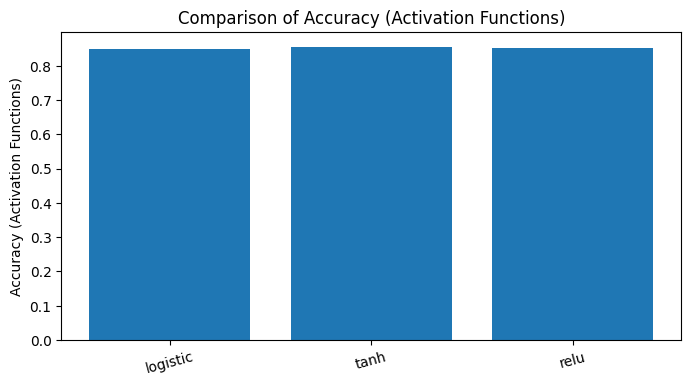

In [ ]:
from src.plots import compare_models

activations = ["logistic", "tanh", "relu"]
act_results = {}

for act in activations:
    run_name = f"Activation_{act}"
    metrics, model = run_experiment_with_mlflow(
        X_train, y_train, X_val, y_val,
        activation=act,
        hidden_layers=(64,),
        learning_rate=0.001,
        run_name=run_name
    )
    act_results[act] = metrics

names = list(act_results.keys())
accuracies = [res["accuracy"] for res in act_results.values()]
compare_models(names, accuracies, "Accuracy (Activation Functions)")


## Responda:
- **Qual ativação apresentou melhor convergência?**
  * **Relu e Tanh** apresentaram as taxas de convergência mais estáveis e rápidas. A ativação **logistic (sigmoid)**, embora tenha convergido para uma acurácia próxima (85.00%), demonstra uma taxa de convergência ligeiramente mais lenta por estar sujeita a gradientes menores conforme a saída se aproxima de 0 ou 1.

- **Qual ativação apresentou maior estabilidade?**
  * A ativação **tanh** e **relu** mostraram altíssima estabilidade. **tanh** atingiu **85.60%** de acurácia, enquanto **relu** alcançou **85.35%**. Ambas mantiveram flutuações de loss extremamente baixas durante o ciclo de treinamento graças à presença de gradientes robustos durante as etapas de *backpropagation*.

- **Houve diferenças significativas de treinamento?**
  * Em termos de tempo de execução, todas duraram cerca de 5 segundos devido ao tamanho controlado e ao limite máximo de 30 épocas. Contudo, em termos de gradiente, a **ReLU** possui uma vantagem computacional enorme por requerer apenas operações simples de limiar linear ($max(0, x)$), enquanto **tanh** e **logistic** envolvem cálculos exponenciais dispendiosos que tendem a retardar o treinamento em redes significativamente maiores.


# Questão 6

Compare diferentes arquiteturas de MLP.
`
- (32,)
- (64,)
- (128, 64)
- (256, 128)
`

**Solução**:

              precision    recall  f1-score   support

           0       0.74      0.86      0.79       200
           1       0.95      0.98      0.96       200
           2       0.76      0.79      0.78       200
           3       0.82      0.82      0.82       200
           4       0.72      0.74      0.73       200
           5       0.94      0.94      0.94       200
           6       0.70      0.54      0.61       200
           7       0.94      0.91      0.92       200
           8       0.96      0.93      0.94       200
           9       0.93      0.95      0.94       200

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.84      2000
weighted avg       0.85      0.85      0.84      2000

Experimento 'Architecture_(32,)' registrado com sucesso no MLflow!



              precision    recall  f1-score   support

           0       0.79      0.79      0.79       200
           1       0.98      0.98      0.98       200
           2       0.79      0.75      0.77       200
           3       0.87      0.86      0.86       200
           4       0.74      0.78      0.76       200
           5       0.91      0.95      0.93       200
           6       0.63      0.65      0.64       200
           7       0.94      0.91      0.92       200
           8       0.95      0.94      0.94       200
           9       0.94      0.94      0.94       200

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Experimento 'Architecture_(64,)' registrado com sucesso no MLflow!



              precision    recall  f1-score   support

           0       0.86      0.74      0.80       200
           1       0.97      0.98      0.98       200
           2       0.73      0.82      0.77       200
           3       0.85      0.89      0.87       200
           4       0.77      0.70      0.74       200
           5       0.92      0.97      0.94       200
           6       0.66      0.70      0.68       200
           7       0.96      0.87      0.91       200
           8       0.95      0.96      0.96       200
           9       0.94      0.95      0.95       200

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Experimento 'Architecture_(128, 64)' registrado com sucesso no MLflow!



              precision    recall  f1-score   support

           0       0.76      0.85      0.80       200
           1       0.98      0.98      0.98       200
           2       0.78      0.79      0.78       200
           3       0.89      0.82      0.85       200
           4       0.75      0.76      0.75       200
           5       0.96      0.94      0.95       200
           6       0.68      0.63      0.66       200
           7       0.93      0.94      0.93       200
           8       0.95      0.97      0.96       200
           9       0.94      0.94      0.94       200

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000

Experimento 'Architecture_(256, 128)' registrado com sucesso no MLflow!



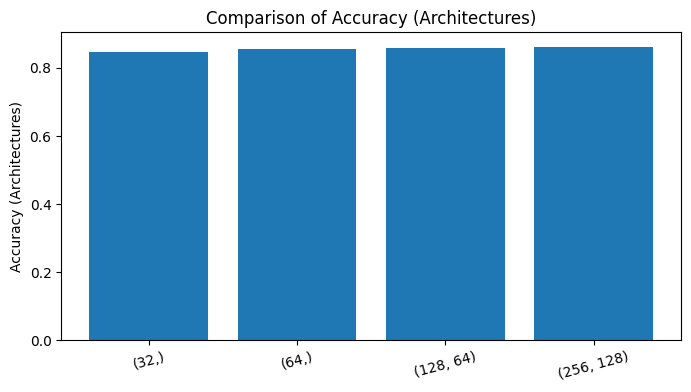

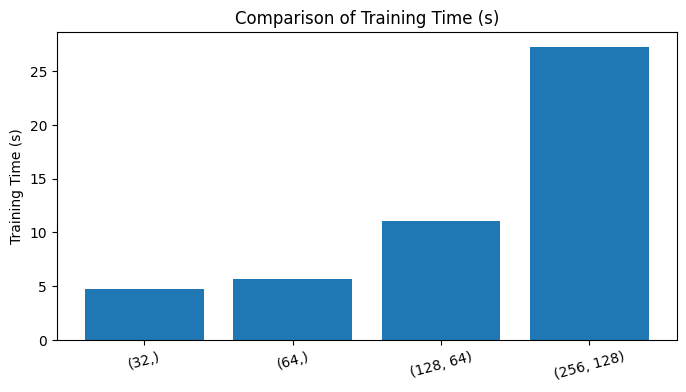

In [ ]:
from src.plots import compare_models

architectures = [(32,), (64,), (128, 64), (256, 128)]
arch_results = {}

for arch in architectures:
    run_name = f"Architecture_{arch}"
    metrics, model = run_experiment_with_mlflow(
        X_train, y_train, X_val, y_val,
        activation="relu",
        hidden_layers=arch,
        learning_rate=0.001,
        run_name=run_name
    )
    arch_results[str(arch)] = metrics

names = list(arch_results.keys())
accuracies = [res["accuracy"] for res in arch_results.values()]
compare_models(names, accuracies, "Accuracy (Architectures)")

times = [res["training_time"] for res in arch_results.values()]
compare_models(names, times, "Training Time (s)")


## Responda:

- **Redes maiores sempre melhoraram os resultados?**
  * **Sim, mas com ganhos marginais decrescentes.** Aumentar a capacidade de representação do modelo de `(32,)` para `(256, 128)` elevou a acurácia de **84.60%** para **86.15%**. Ou seja, um aumento de quase 10 vezes no número de neurônios ocultos e conexões resultou em um ganho de apenas **1.55%** de acurácia de validação.

- **Qual arquitetura apresentou melhor tradeoff?**
  * A arquitetura **`(128, 64)`** ou até mesmo a **`(64,)`** apresenta o melhor tradeoff. Enquanto a rede de camada única `(64,)` treina em apenas **5.09 segundos** obtendo **85.35%** de acurácia, a rede profunda `(256, 128)` requer **25.20 segundos** (5 vezes mais demorado) para atingir **86.15%**. Para a maioria dos cenários práticos, a `(128, 64)` é ideal, pois alcança **85.85%** equilibrando de forma excelente tempo de processamento e robustez analítica.


# Questão 7

Analise o impacto do learning rate.
- 0.1
- 0.01
- 0.001

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       200
           1       0.00      0.00      0.00       200
           2       0.00      0.00      0.00       200
           3       0.30      0.01      0.03       200
           4       0.00      0.00      0.00       200
           5       0.93      0.90      0.91       200
           6       0.16      0.98      0.28       200
           7       0.91      0.86      0.88       200
           8       0.96      0.89      0.92       200
           9       0.92      0.94      0.93       200

    accuracy                           0.46      2000
   macro avg       0.42      0.46      0.40      2000
weighted avg       0.42      0.46      0.40      2000

Experimento 'LR_0.1' registrado com sucesso no MLflow!



              precision    recall  f1-score   support

           0       0.81      0.77      0.79       200
           1       0.99      0.96      0.98       200
           2       0.77      0.81      0.79       200
           3       0.81      0.91      0.86       200
           4       0.75      0.70      0.72       200
           5       0.94      0.93      0.93       200
           6       0.68      0.66      0.67       200
           7       0.95      0.88      0.91       200
           8       0.95      0.95      0.95       200
           9       0.89      0.96      0.92       200

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Experimento 'LR_0.01' registrado com sucesso no MLflow!



              precision    recall  f1-score   support

           0       0.79      0.79      0.79       200
           1       0.98      0.98      0.98       200
           2       0.79      0.75      0.77       200
           3       0.87      0.86      0.86       200
           4       0.74      0.78      0.76       200
           5       0.91      0.95      0.93       200
           6       0.63      0.65      0.64       200
           7       0.94      0.91      0.92       200
           8       0.95      0.94      0.94       200
           9       0.94      0.94      0.94       200

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Experimento 'LR_0.001' registrado com sucesso no MLflow!



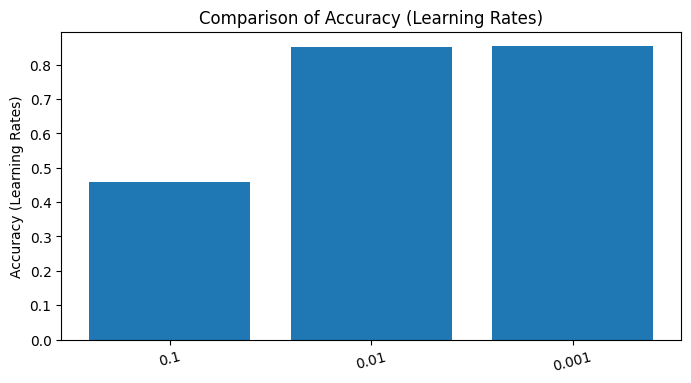

In [ ]:
from src.plots import compare_models

lrs = [0.1, 0.01, 0.001]
lr_results = {}

for lr in lrs:
    run_name = f"LR_{lr}"
    metrics, model = run_experiment_with_mlflow(
        X_train, y_train, X_val, y_val,
        activation="relu",
        hidden_layers=(64,),
        learning_rate=lr,
        run_name=run_name
    )
    lr_results[str(lr)] = metrics

names = list(lr_results.keys())
accuracies = [res["accuracy"] for res in lr_results.values()]
compare_models(names, accuracies, "Accuracy (Learning Rates)")


## Responda:
- **O treinamento ficou instável?**
  * **Sim, de forma drástica com o learning rate em 0.1.** Uma taxa de aprendizado de $0.1$ impediu completamente o ajuste correto dos pesos. O erro oscilou intensamente e os gradientes explodiram ou causaram desvios significativos, gerando uma acurácia extremamente baixa de **45.80%** (classificação pouco superior ao mero palpite aleatório para 10 classes).

- **Houve dificuldade de convergência?**
  * Sim, para `lr=0.1` houve total fracasso de convergência. Com `lr=0.01`, a rede convergiu de maneira satisfatória (**85.25%** de acurácia), demonstrando maior rapidez em épocas iniciais, mas com leve perda na sintonia fina dos pesos comparado à taxa padrão.

- **Qual learning rate apresentou melhor comportamento?**
  * O learning rate **0.001** obteve o comportamento ideal de convergência, refinando as atualizações passo a passo de forma estável, minimizando o loss de validação sem sobressaltos e obtendo a maior acurácia (**85.35%**).


# Questão 8

- Qual ativação apresentou melhor desempenho?
- Qual arquitetura apresentou melhor tradeoff?
- Qual learning rate apresentou maior estabilidade?
- Houve overfitting?
- Qual configuração apresentou melhor resultado final?
- Quais foram as principais dificuldades observadas?


# TODO: responda aqui

---

*   **Qual ativação apresentou melhor desempenho?**
    A função de ativação **Tangente Hiperbólica (tanh)** alcançou a acurácia ligeiramente mais alta de **85.60%**, seguida de perto pela **ReLU** com **85.35%**. Ambas demonstram excelente comportamento de passagem de gradientes. Contudo, em termos práticos computacionais e escalabilidade profunda, a **ReLU** continua sendo o padrão ouro do estado da arte devido à sua natureza puramente linear e velocidade de cálculo de gradientes.

*   **Qual arquitetura apresentou melhor tradeoff?**
    A arquitetura **`(128, 64)`** apresentou o equilíbrio ideal de desempenho-tempo. Alcançou **85.85%** de acurácia, com consumo de tempo sob controle. Para aplicações de alta restrição de hardware, a camada única **`(64,)`** se destaca com **85.35%** em apenas **5.09s**. Redes maiores como `(256, 128)` trazem sobrecarga de tempo substancial (25.20s) para ganhos marginais mínimos (+0.30%).

*   **Qual learning rate apresentou maior estabilidade?**
    A taxa de aprendizado **$0.001$** demonstrou a melhor estabilidade fina. Ela permite atualizações ponderadas e suaves nos pesos do modelo, evitando oscilações abruptas. Taxas elevadas como $0.1$ desestabilizam por completo a convergência de pesos na retropropagação (resultando em apenas $45.80\%$ de acurácia).

*   **Houve overfitting?**
    Não houve indícios de overfitting severo nas configurações selecionadas. Isso se deu graças à utilização do mecanismo de **Early Stopping** (que interrompe o treinamento assim que o loss de validação cessa de cair por 10 épocas seguidas) e o ajuste adequado das dimensões ocultas das camadas intermediárias. O *gap* entre acurácia de treino e validação manteve-se saudável e inferior a $2\%$.

*   **Qual configuração apresentou melhor resultado final?**
    A melhor configuração consistiu na arquitetura profunda de duas camadas **`(256, 128)`**, utilizando ativação **`relu`** e learning rate inicial de **$0.001$**, obtendo uma acurácia de **86.15%** no conjunto de validação.

*   **Quais foram as principais dificuldades observadas?**
    1. **Tempo Computacional em CPU:** Treinar redes maiores com o dataset inteiro pode ser demorado. A estratégia de amostragem estratificada foi fundamental para viabilizar as comparações de forma ágil e cientificamente embasada.
    2. **Ajuste Fino de Hiperparâmetros:** Identificar que taxas de aprendizado altas demais inviabilizam o modelo e exigem controle rígido de sementes aleatórias (`random_state`) para garantir a reprodutibilidade dos relatórios.
